# 1 Initialize the Database

All the code related to data management is in the `EnvironmentData` class. This makes life easier - for example: we can send the CatsUserID once and it becomes a class property. Then, when we call other operations we don't have to send this information again.

When you create a new instance of `EnvironmentData` and there is no database, it'll pull historical data and initialize the database. 

In [1]:
from EnvironmentData import EnvironmentData 
#envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'], testing = True)
envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'])

Gather readings: SensorReadingRh: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [01:04<00:00,  1.01it/s]


Detailed information is saved in the log:

In [2]:
# Detailed info is saved in the log.
with open('data/EnvironmentData.log', 'r') as file:
    print(file.read().splitlines()[:10])

['2024-10-14 18:07:38,723 - EnvironmentData - INFO - initialize_database', '2024-10-14 18:07:38,723 - EnvironmentData - INFO - get_sensors', '2024-10-14 18:07:38,724 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/cats/user/?ApiKey=XXXX&CatsUserID=XXXX', '2024-10-14 18:07:39,538 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21373&ReadingType=SensorReadingF&StartUTC=1721174858&EndUTC=1728950858&MinReadingSpacing=600&RequestedOutputFormat=raw', '2024-10-14 18:07:40,518 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21375&ReadingType=SensorReadingF&StartUTC=1721174858&EndUTC=1728950858&MinReadingSpacing=600&RequestedOutputFormat=raw', '2024-10-14 18:07:41,477 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21377&ReadingType=SensorReadingF&StartUTC=1721174858&EndUTC=

Raw data is now in the database in `data/sensor_readings.parquet`. 

Initially, we leave the data mostly as-is. We'll clean when moving to analytical steps, this preserves the source data so we can always change our mind about how we decide to view it. 

There are just a few columns because this is only historical data. We'll bring in current data shortly, and that will add more columns. 

In [3]:
import polars
polars.read_parquet('data/sensor_readings.parquet')

SensorReadingUTC,SensorReadingF,SensorID_Coris,SensorName,DeviceName,DeviceID_Coris,SensorType,SensorReadingRh
i64,f32,i32,str,str,i32,str,f32
1721174858,69.57,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1721175458,69.669998,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1721176058,69.660004,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1721176658,69.660004,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1721177258,69.669998,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
…,…,…,…,…,…,…,…
1728947858,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",39.099998
1728948458,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",39.700001
1728949058,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",40.299999


# 2 Get Current Readings

Now we can start gathering and appending readings. There is a function `get_current_readings` that is run throughout the day, every 10 minutes for example. This function creates a parquet file at `data/new-readings` with the UTC as a filename. At the end of the day, all these readings will be consolidated into the database. 

Here is a sample of the readings:

In [4]:
envdt.get_current_readings()

# Data is read into new-readings folder for consolidation at the end of the day.
import os
filename = os.listdir('data/new-readings')[0]
print(filename)
polars.read_parquet('data/new-readings/' + filename).sample(5)

1728950989.parquet


SensorName,SensorID_Coris,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,SensorReadingUTC,DeviceName,DevTypeInt,DeviceID_Coris,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorType,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorReadingF,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorReadingRh,SensorCalibrationOffsetRh,SensorEventCount,SensorState
str,i32,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,i64,i32,str,null,str,str,null,str,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f32,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,f32,i64,i64,str
""" RH YPM 106_D0B5""",21382,0,1728950989,"""000000000000""","""00800000000207AF""",1728950988,false,"""Excellent""","""0025CA0A0000D0B5""",false,false,53.49,1728950959,"""Peabody TH-L Lower Great Hall …",96,12165,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,0,55,1728950959,0,null,null,33514,null,null,null,null,null,null,null,null,0,53.490002,0,null,null
"""RH YPM 304_D0A7 """,21380,0,1728950989,"""000000000000""","""0080000000016797""",1728950924,false,"""Excellent""","""0025CA0A0000D0A7""",false,false,49.77,1728950846,"""new Peabody TH-L DFH Room 303…",96,12168,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,0,17,1728950846,0,null,null,33512,null,null,null,null,null,null,null,null,0,49.77,0,null,null
"""RH YPM 111_86a674""",28880,0,1728950989,"""000000000000""","""00800000000207AF""",1728950988,null,"""Excellent""","""A84041469186A674""",false,false,48.1,1728950906,"""YalePeabody 8.23.23 A674""",112,14491,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1728950894,0,null,null,43329,null,null,null,null,null,null,null,null,0,48.099998,0,null,null
"""Temp CSC K215_00cd95""",23386,0,1728950989,"""000000000000""","""0080000000019E79""",1728950953,false,"""Excellent""","""0025CA0A0000CD95""",false,false,21.76,1728950802,"""L_0025CA0A0000CD95""",96,12421,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,21.8,0.0,71.199997,0.0,null,null,null,null,1,0,70,1728948401,0,null,null,35778,null,45.03,45.03,23387,1728950802,70.1,21.2,0,0,null,null,null,null
"""RH CSC K221_00cd6c""",23403,0,1728950989,"""000000000000""","""0080000000019E79""",1728950953,false,"""Excellent""","""0025CA0A0000CD6C""",false,false,44.47,1728950813,"""L_0025CA0A0000CD6C""",96,12409,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,0,70,1728938567,0,null,null,35795,null,null,null,null,null,null,null,null,0,44.470001,0,n

# 3 Consolidate Readings

At the end of the day, new readings will be consolidated into the table. At the same time, the analytical tables will be generated. 

Analytical tables include:

* `device_readings.parquet`: Sensor readings reorganized to one row per Device and UTC, with measurements across columns vs measurements across rows.* 
* `sensors.parquet`: Information about the unique sensors. Includes information extracted from SensorName. Join this to Sensors during analysis to enhance with Building, Room, Direction, etc.
* `devices.parquet`: Information about unique devices. Includes information extracted from SensorName. 
* `utc_info.parquet`: Information related to the UTC times in various datasets. Join to Sensors or Devices to enhance with Date, Time, Year, Hour, Weekday, etc. 

We fully re-generate analytical tables during each consolidation. The data is small enough that this is a fairly quick process, so re-running it in full each time will make it easy to ensure consistency as we expand and change the project. 

In [5]:
# To consolidate these into the database, run consolidate_readings.
envdt.consolidate_readings()

# New-readings files are gone now.
# They get deleted each day to confirm that they have been loaded into the database and prepare for the next consolidation.
print(os.listdir('data/new-readings'))

[]


Let's look at the data we have now:

In [6]:
# Sensor Readings
# The first rows will be missing the extra fields like HexGatewayMac, etc.
#   I am pulling in some extra fields like DeviceID and DeviceName so we have that by historical. 
#   But some don't make sense to  backfill so they'll be null.
sensor_readings = polars.read_parquet('data/sensor_readings.parquet')
sensor_readings.head()

SensorID_Coris,SensorReadingUTC,DeviceID_Coris,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i64,i32,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
21373,1721174858,12162,69.57,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,1721175458,12162,69.669998,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,1721176058,12162,69.660004,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,1721176658,12162,69.660004,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,1721177258,12162,69.669998,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [8]:
# Recent rows will have the full data, aside from nulls due to a sensor not providing a reading type\.
sensor_readings.tail()

SensorID_Coris,SensorReadingUTC,DeviceID_Coris,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i64,i32,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
30134,1728950992,15177,null,41.200001,"""RH ESC 281_C347""","""Yale Peabody C347 6.19.24""","""Humidity""",0,1728950989,"""000000000000""","""0080000000019E54""",1728950989,null,"""Excellent""","""A84041118559C347""",false,false,41.2,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728950989,0,null,null,45271,null,null,null,null,null,null,null,null,0,0,null,null
30135,1728950826,15178,69.599998,null,"""Temp KGL 27_C349""","""Yale Peabody C349 6.19.24""","""Temperature""",0,1728950989,"""000000000000""","""0080000000019E44""",1728950960,null,"""Excellent""","""A84041096459C349""",false,false,20.9,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,20.9,0.0,0.0,null,null,null,null,1,null,85,1728950800,0,null,null,45272,null,45.4,45.4,30136,1728950826,69.6,20.9,0,0,null,null,null
30136,1728950826,15178,null,45.400002,"""RH KGL 27_C349""","""Yale Peabody C349 6.19.24""","""Humidity""",0,1728950989,"""000000000000""","""0080000000019E44""",1728950960,null,"""Excellent""","""A84041096459C349""",false,false,45.4,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728950800,0,null,null,45273,null,null,null,null,null,null,null,null,0,0,null,null
30137,1728950746,15179,66.599998,null,"""Temp ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Temperature""",0,1728950989,"""000000000000""","""0080000000016797""",1728950924,null,"""Good""","""A84041EA9659C352""",false,false,19.22,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,19.2,0.0,0.0,null,null,null,null,1,null,85,1728950708,0,null,null,45274,null,46.7,46.7,30138,1728950746,66.6,19.2,0,0,null,null,null
30138,1728950746,15179,null,46.700001,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",0,1728950989,"""000000000000""","""0080000000016797""",1728950924,null,"""Good""","""A84041EA9659C352""",false,false,46.7,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1728950708,0,null,null,45275,null,null,null,null,null,null,null,null,0,

In [9]:
# Device Readings.
device_readings = polars.read_parquet('data/device_readings.parquet')
device_readings.head()

DeviceID_Coris,DeviceName,SensorReadingUTC,SensorReadingF,SensorReadingRh
i32,str,i64,f32,f32
12162,"""Peabody TH-L Mammal Hall D444""",1721174858,69.57,49.34
12162,"""Peabody TH-L Mammal Hall D444""",1721175458,69.669998,49.549999
12162,"""Peabody TH-L Mammal Hall D444""",1721176058,69.660004,49.369999
12162,"""Peabody TH-L Mammal Hall D444""",1721176658,69.660004,49.34
12162,"""Peabody TH-L Mammal Hall D444""",1721177258,69.669998,49.630001


In [10]:
# Sensors
sensors = polars.read_parquet('data/sensors.parquet')
sensors.head()

SensorID_Coris,Building,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris
i32,str,str,str,str,str,str,i32
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416


In [11]:
# Devices. 
devices = polars.read_parquet('data/sensors.parquet')
devices.head()

SensorID_Coris,Building,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris
i32,str,str,str,str,str,str,i32
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416


In [12]:
# UTC Date/Time Info
utc_lookup = polars.read_parquet('data/utc_lookup.parquet').head()
utc_lookup.head()

UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
i64,datetime[μs],"datetime[μs, America/New_York]",date,time,i32,i8,str,i8,i8,i8,str
1700063665,2023-11-15 08:54:25,2023-11-15 03:54:25 EST,2023-11-15,03:54:25,2023,11,"""Wednesday""",3,3,3,"""AM"""
1718935710,2024-06-20 20:08:30,2024-06-20 16:08:30 EDT,2024-06-20,16:08:30,2024,6,"""Thursday""",4,16,4,"""PM"""
1721174858,2024-07-16 18:07:38,2024-07-16 14:07:38 EDT,2024-07-16,14:07:38,2024,7,"""Tuesday""",2,14,2,"""PM"""
1721175458,2024-07-16 18:17:38,2024-07-16 14:17:38 EDT,2024-07-16,14:17:38,2024,7,"""Tuesday""",2,14,2,"""PM"""
1721176058,2024-07-16 18:27:38,2024-07-16 14:27:38 EDT,2024-07-16,14:27:38,2024,7,"""Tuesday""",2,14,2,"""PM"""


Once we are done working with data intake/processing, we close the class to release lgo file connections:

In [13]:
# When done, close the connection to the logs. 
envdt.close()

# 4 Analytics

Now we are ready to pull data and run analytics. Here are a few examples: 

<Axes: ylabel='Count'>

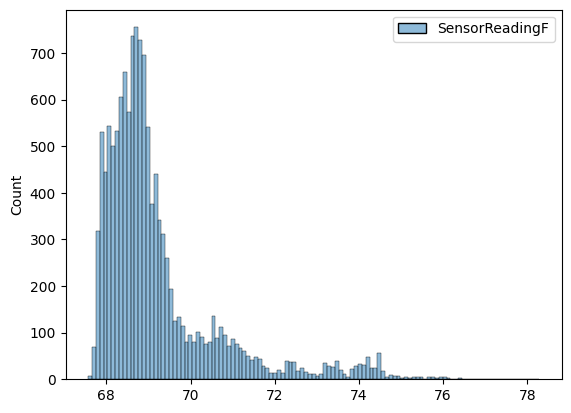

In [15]:
# Histogram of temperature. 
import seaborn, duckdb
dt = duckdb.sql("""
    SELECT SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.histplot(dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

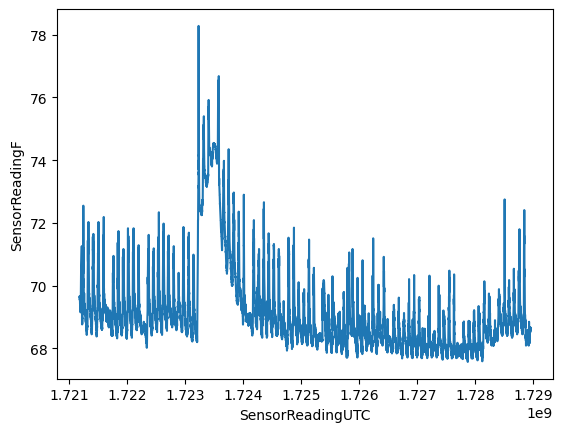

In [16]:
# Time series plot. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

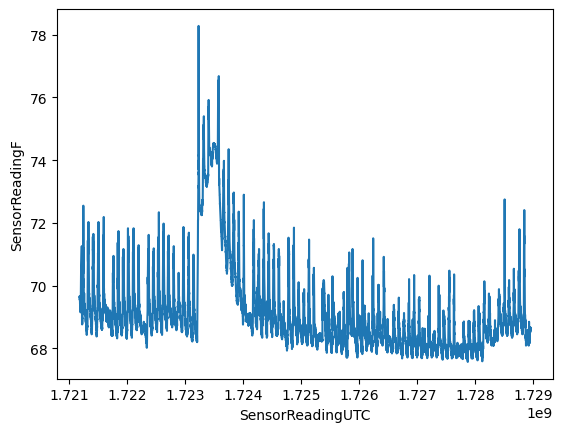

In [17]:
# Time series plot, queried from Devices instead of Sensors. 
# This is the same data, just organized in a different way. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/device_readings.parquet') 
    WHERE SensorReadingF is not null and DeviceID_Coris = 12162;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())